In [1]:
import cnotebook
import oepandas as oepd
from openeye import oechem

# Using OEPandas with Maestro Formats

This only requires a valid OpenEye Toolkit license. You do not need to have any Schrodinger software installed.

<div class="alert alert-block alert-info">
    <b>As long as you have <tt>oepandas</tt> installed, you don't need to do anything special!</b>
</dev>

,Molecule,Title,Chiralities_Consistent,chiral_flag,mmshare_version,ct_format,ct_stereo_status,source_file_index,NumAcceptors,NumDonors,Energy,MolWt,Force_Field,Variant,source_file,Chirality_1
0,,Aspirin,1,0,73163,2,1,1,2,1,14.789976,180.15742,S-OPLS,Aspirin-1,Test_2.maegz,NaN
1,,Ibuprofen,1,1,73163,2,1,2,1,1,14.295146,206.28082,S-OPLS,Ibuprofen-1,Test_2.maegz,11_S_13_8_12_29
2,,Acetaminophen,1,0,73163,2,1,3,1,2,8.886315,151.16256,S-OPLS,Acetaminophen-1,Test_2.maegz,NaN
3,,Caffeine,1,0,73163,2,1,4,3,0,12.226015,194.1906,S-OPLS,Caffeine-1,Test_2.maegz,NaN
4,,Diazepam,1,0,73163,2,1,5,2,0,57.193646,284.74022,S-OPLS,Diazepam-1,Test_2.maegz,NaN

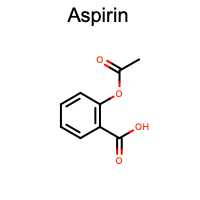
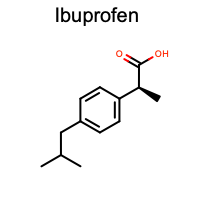
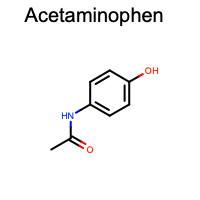
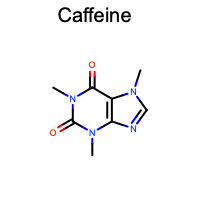
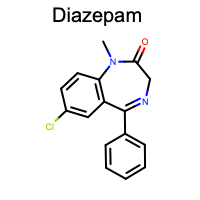

In [2]:
df = oepd.read_mae("../tests/assets/5.maegz")
df.head()

The molecules are regular OpenEye molecules, so you can use them in the standard ``oepandas``/``cnotebook`` way:

,Molecule,Title,Chiralities_Consistent,chiral_flag,mmshare_version,ct_format,ct_stereo_status,source_file_index,NumAcceptors,NumDonors,Energy,MolWt,Force_Field,Variant,source_file,Chirality_1,NumCarbons
0,,Aspirin,1,0,73163,2,1,1,2,1,14.789976,180.15742,S-OPLS,Aspirin-1,Test_2.maegz,NaN,9
1,,Ibuprofen,1,1,73163,2,1,2,1,1,14.295146,206.28082,S-OPLS,Ibuprofen-1,Test_2.maegz,11_S_13_8_12_29,13
2,,Acetaminophen,1,0,73163,2,1,3,1,2,8.886315,151.16256,S-OPLS,Acetaminophen-1,Test_2.maegz,NaN,8
3,,Caffeine,1,0,73163,2,1,4,3,0,12.226015,194.1906,S-OPLS,Caffeine-1,Test_2.maegz,NaN,8
4,,Diazepam,1,0,73163,2,1,5,2,0,57.193646,284.74022,S-OPLS,Diazepam-1,Test_2.maegz,NaN,16

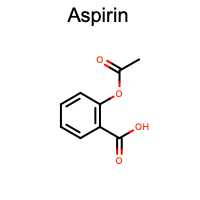
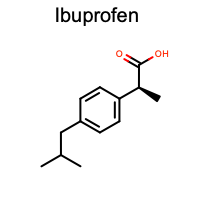
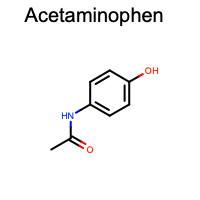
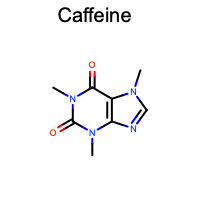
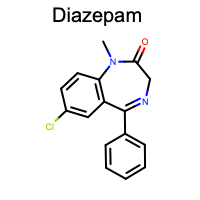

In [3]:
df["NumCarbons"] = df.Molecule.apply(lambda x: oechem.OECount(x, oechem.OEIsCarbon()))

# Display the table
df.head()

You can also control how tags are named using the constants in the ``oepandas_mae`` module. Here is how to get the full Maestro tag name.

In [4]:
import oepandas_mae as oemae

,Molecule,Title,b_lp_Chiralities_Consistent,b_sd_chiral_flag,i_lp_mmshare_version,i_m_ct_format,i_m_ct_stereo_status,i_m_source_file_index,i_sd_NumAcceptors,i_sd_NumDonors,r_lp_Energy,r_sd_MolWt,s_lp_Force_Field,s_lp_Variant,s_m_source_file,s_st_Chirality_1
0,,Aspirin,1,0,73163,2,1,1,2,1,14.789976,180.15742,S-OPLS,Aspirin-1,Test_2.maegz,NaN
1,,Ibuprofen,1,1,73163,2,1,2,1,1,14.295146,206.28082,S-OPLS,Ibuprofen-1,Test_2.maegz,11_S_13_8_12_29
2,,Acetaminophen,1,0,73163,2,1,3,1,2,8.886315,151.16256,S-OPLS,Acetaminophen-1,Test_2.maegz,NaN
3,,Caffeine,1,0,73163,2,1,4,3,0,12.226015,194.1906,S-OPLS,Caffeine-1,Test_2.maegz,NaN
4,,Diazepam,1,0,73163,2,1,5,2,0,57.193646,284.74022,S-OPLS,Diazepam-1,Test_2.maegz,NaN

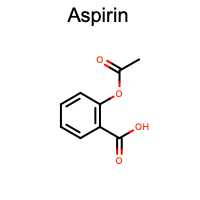
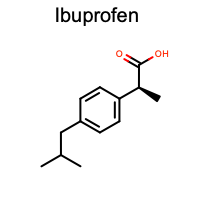
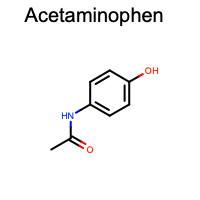
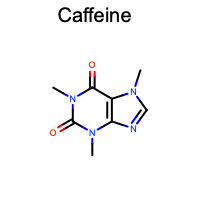
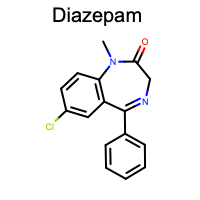

In [5]:
df2 = oepd.read_mae("../tests/assets/5.maegz", tags=oemae.TAG_ALL)
df2.head()

Note that ``oepandas-mae`` respects the data types specified by the Maestro data tags.

In [10]:
df2.dtypes

Molecule                       molecule
Title                               str
b_lp_Chiralities_Consistent       int64
b_sd_chiral_flag                  int64
i_lp_mmshare_version              int64
i_m_ct_format                     int64
i_m_ct_stereo_status              int64
i_m_source_file_index             int64
i_sd_NumAcceptors                 int64
i_sd_NumDonors                    int64
r_lp_Energy                     float64
r_sd_MolWt                      float64
s_lp_Force_Field                    str
s_lp_Variant                        str
s_m_source_file                     str
s_st_Chirality_1                    str
dtype: object